The second edition of *Think Complexity* is available from [Bookshop.org](https://bookshop.org/a/98697/9781492040200) and [Amazon](https://amzn.to/3wPN0SJ) (those are affiliate links). If you are enjoying the free, online version, consider [buying me a coffee](https://buymeacoffee.com/allendowney).

# Evolution of cooperation

In this final chapter, I take on two questions, one from biology and one from philosophy:

-   In biology, the "problem of altruism" is the apparent conflict between natural selection, which suggests that animals live in a state of constant competition, and altruism, which is the tendency of many animals to help other animals, even to their own detriment. See <https://thinkcomplex.com/altruism>.

-   In moral philosophy, the question of human nature asks whether humans are fundamentally good, or evil, or blank states shaped by their environment. See <https://thinkcomplex.com/nature>.

The tools I use to address these questions are agent-based simulation (again) and game theory, which is a set of abstract models meant to describe ways agents interact. Specifically, the game we will consider is the Prisoner's Dilemma.

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ThinkComplexity2/blob/master/soln/chap12.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)
    
download('https://github.com/AllenDowney/ThinkComplexity2/raw/master/notebooks/utils.py')


In [3]:
from utils import decorate, savefig
# make a directory for figures
!mkdir -p figs

## Prisoner's Dilemma

The Prisoner's Dilemma is a topic in game theory, but it's not the fun kind of game. Instead, it is the kind of game that sheds light on human motivation and behavior. Here is the presentation of the dilemma from Wikipedia (<https://thinkcomplex.com/pd>):

> Two members of a criminal gang are arrested and imprisoned. Each prisoner is in solitary confinement with no means of communicating with the other. The prosecutors lack sufficient evidence to convict the pair on the principal charge, but they have enough to convict both on a lesser charge. Simultaneously, the prosecutors offer each prisoner a bargain. Each prisoner is given the opportunity to either: (1) betray the other by testifying that the other committed the crime, or (2) cooperate with the other by remaining silent. The offer is:
>
> -   If A and B each betray the other, each of them serves 2 years in prison.
>
> -   If A betrays B but B remains silent, A will be set free and B will serve 3 years in prison (and vice versa).
>
> -   If A and B both remain silent, both of them will only serve 1 year in prison (on the lesser charge).

Obviously, this scenario is contrived, but it is meant to represent a variety of interactions where agents have to choose whether to "cooperate" with each other or "defect", and where the reward (or punishment) for each agent depends on what the other chooses.

With this set of punishments, it is tempting to say that the players should cooperate, that is, that both should remain silent. But neither agent knows what the other will do, so each has to consider two possible outcomes. First, looking at it from A's point of view:

-   If B remains silent, A is better off defecting; she would go free rather than serve 1 year.

-   If B defects, A is still better off defecting; she would serve only 2 years rather than 3.

No matter what B does, A is better off defecting. And because the game is symmetric, this analysis is the same from B's point of view: no matter what A does, B is better off defecting.

In the simplest version of this game, we assume that A and B have no other considerations to take into account. They can't communicate with each other, so they can't negotiate, make promises, or threaten each other. And they consider only the immediate goal of minimizing their sentences; they don't take into account any other factors.

Under those assumptions, the rational choice for both agents is to defect. That might be a good thing, at least for purposes of criminal justice. But for the prisoners, it is frustrating because there is, apparently, nothing they can do to achieve the outcome they both want. And this model applies to other scenarios in real life where cooperation would be better for the greater good as well as for the players.

Studying these scenarios, and ways to escape from the dilemma, is the focus of people who study game theory, but it is not the focus of this chapter. We are headed in a different direction.

## The problem of nice

Since the Prisoner's Dilemma was first discussed in the 1950s, it has been a popular topic of study in social psychology. Based on the analysis in the previous section, we can say what a perfectly rational agent *should* do; it is harder to predict what real people actually do. Fortunately, the experiment has been done. (Here's a recent report with references to previous experiments: Barreda-Tarrazona, Jaramillo-Gutiérrez, Pavan, and Sabater-Grande, "Individual Characteristics vs. Experience: An Experimental Study on Cooperation in Prisoner's Dilemma", Frontiers in Psychology, 2017; 8: 596. <https://thinkcomplex.com/pdexp>.)

If we assume that people are smart enough to do the analysis (or understand it when explained), and that they generally act in their own interest, we would expect them to defect pretty much all the time. But they don't. In most experiments, subjects cooperate much more than the rational agent model predicts. (For an excellent video summarizing what we have discussed so far, see <https://thinkcomplex.com/pdvid1>.)

The most obvious explanation of this result is that people are not rational agents, which should not be a surprise to anyone. But why not? Is it because they are not smart enough to understand the scenario or because they are knowingly acting contrary to their own interest?

Based on experimental results, it seems that at least part of the explanation is plain altruism: many people are willing to incur a cost to themselves in order to benefit another person. Now, before you nominate that conclusion for publication in the *Journal of Obvious Results*, let's keep asking why:

-   Why do people help other people, even at a cost to themselves? At least part of the reason is that they want to; it makes them feel good about themselves and the world.

-   And why does being nice make people feel good? It might be tempting to say that they were raised right, or more generally trained by society to want to do good things. But there is little doubt that some part of altruism is innate; a proclivity for altruism is the result of normal brain development.

-   Well, why is that? The innate parts of brain development, and the personal characteristics that follow, are the result of genetic information. Of course, the relationship between genes and altruism is complicated; there are probably many genes that interact with each other and with environmental factors to cause people to be more or less altruistic in different circumstances. Nevertheless, there are almost certainly genes that tend to make people altruistic.

-   Finally, why is that? If, under natural selection, animals are in constant competition with each other to survive and reproduce, it seems obvious that altruism would be counterproductive. In a population where some people help others, even to their own detriment, and others are purely selfish, it seems like the selfish ones would benefit, the altruistic ones would suffer, and the genes for altruism would be driven to extinction.

This apparent contradiction is the "problem of altruism": *why haven't the genes for altruism died out*?

Among biologists, there are many possible explanations, including reciprocal altruism, sexual selection, kin selection, and group selection. Among non-scientists, there are even more explanations. I leave it to you to explore the alternatives; for now I want to focus on just one explanation, arguably the simplest one: maybe altruism is adaptive. In other words, maybe genes for altruism make people more likely to survive and reproduce.

It turns out that the Prisoner's Dilemma, which raises the problem of altruism, might also help resolve it.

## Prisoner's dilemma tournaments

In the late 1970s Robert Axelrod, a political scientist at the University of Michigan, organized a tournament to compare strategies for playing Prisoner's Dilemma (PD).

He invited participants to submit strategies in the form of computer programs, then played the programs against each other and kept score. Specifically, they played the iterated version of PD, in which the agents play multiple rounds against the same opponent, so their decisions can be based on history.

In Axelrod's tournaments, a simple strategy that did surprisingly well was called "tit for tat", or TFT. TFT always cooperates during the first round of an iterated match; after that, it copies whatever the opponent did during the previous round. If the opponent keeps cooperating, TFT keeps cooperating. If the opponent defects at any point, TFT defects in the next round. But if the opponent goes back to cooperating, so does TFT.

For more information about these tournaments, and an explanation of why TFT does so well, see this video: <https://thinkcomplex.com/pdvid2>.

Looking at the strategies that did well in these tournaments, Alexrod identified the characteristics they tended to share:

-   Nice: The strategies that do well cooperate during the first round, and generally cooperate as often as they defect in subsequent rounds.

-   Retaliating: Strategies that cooperate all the time did not do as well as strategies that retaliate if the opponent defects.

-   Forgiving: But strategies that were too vindictive tended to punish themselves as well as their opponents.

-   Non-envious: Some of the most successful strategies seldom outscore their opponents; they are successful because they do *well enough* against a wide variety of opponents.

TFT has all of these properties.

Axelrod's tournaments offer a partial, possible answer to the problem of altruism: maybe the genes for altruism are prevalent because they are adaptive. To the degree that many social interactions can be modeled as variations on the Prisoner's Dilemma, a brain that is wired to be nice, tempered by a balance of retaliation and forgiveness, will tend to do well in a wide variety of circumstances.

But the strategies in Axelrod's tournaments were designed by people; they didn't evolve. We need to consider whether it is credible that genes for niceness, retribution, and forgiveness could appear by mutation, successfully invade a population of other strategies, and resist being invaded by subsequent mutations.

## Simulating evolution of cooperation

*Evolution of Cooperation* is the title of the first book where Axelrod presented results from Prisoner's Dilemma tournaments and discussed the implications for the problem of altruism. Since then, he and other researchers have explored the evolutionary dynamics of PD tournaments, that is, how the distribution of strategies changes over time in a population of PD contestants. In the rest of this chapter, I run a version of those experiments and present the results.

First, we'll need a way to encode a PD strategy as a genotype. For this experiment, I consider strategies where the agent's choice in each round depends only on the opponent's choice in the previous two rounds. I represent a strategy using a dictionary that maps from the opponent's previous two choices to the agent's next choice.

Here is the class definition for these agents:

In [4]:
class Agent:
    
    keys = [(None, None),
            (None, 'C'),
            (None, 'D'),
            ('C', 'C'),
            ('C', 'D'),
            ('D', 'C'),
            ('D', 'D')]
    
    def __init__(self, values, fitness=np.nan):
        """Initialize the agent.
        
        values: sequence of 'C' and 'D'
        """
        self.values = values
        self.responses = dict(zip(self.keys, values))
        self.fitness = fitness
        
    def reset(self):
        """Reset variables before a sequence of games.
        """
        self.hist = [None, None]
        self.score = 0
        
    def past_responses(self, num=2):
        """Select the given number of most recent responses.
        
        num: integer number of responses
        
        returns: sequence of 'C' and 'D'
        """
        return tuple(self.hist[-num:])
    
    def respond(self, other):
        """Choose a response based on the opponent's recent responses.
        
        other: Agent
        
        returns: 'C' or 'D'
        """
        key = other.past_responses()
        resp = self.responses[key]
        return resp
        
    def append(self, resp, pay):
        """Update based on the last response and payoff.
        
        resp: 'C' or 'D'
        pay: number
        """
        self.hist.append(resp)
        self.score += pay

`keys` is the sequence of keys in each agent's dictionary, where the tuple `('C', 'C')` means that the opponent cooperated in the previous two rounds; `(None, 'C')` means that only one round has been played and the opponent cooperated; and `(None, None)` means that no rounds have been played.

In the `__init__` method, `values` is a sequence of choices, either `'C'` or `'D'`, that correspond to `keys`. So if the first element of `values` is `'C'`, that means that this agent will cooperate in the first round. If the last element of `values` is `'D'`, this agent will defect if the opponent defected in the previous two rounds.

In this implementation, the genotype of an agent who always defects is `'DDDDDDD'`; the genotype of an agent who always cooperates is `'CCCCCCC'`, and the genotype for TFT is `'CCDCDCD'`.

Here's the genome for "always cooperate"

In [5]:
all_c = Agent('CCCCCCC')
all_c.responses

{(None, None): 'C',
 (None, 'C'): 'C',
 (None, 'D'): 'C',
 ('C', 'C'): 'C',
 ('C', 'D'): 'C',
 ('D', 'C'): 'C',
 ('D', 'D'): 'C'}

And for "always defect"

In [6]:
all_d = Agent('DDDDDDD')
all_d.responses

{(None, None): 'D',
 (None, 'C'): 'D',
 (None, 'D'): 'D',
 ('C', 'C'): 'D',
 ('C', 'D'): 'D',
 ('D', 'C'): 'D',
 ('D', 'D'): 'D'}

And for "tit for tat"

In [7]:
tft = Agent('CCDCDCD')
tft.responses

{(None, None): 'C',
 (None, 'C'): 'C',
 (None, 'D'): 'D',
 ('C', 'C'): 'C',
 ('C', 'D'): 'D',
 ('D', 'C'): 'C',
 ('D', 'D'): 'D'}

The `Agent` class provides `copy`, which makes another agent with the same genotype, but with some probability of mutation:

In [8]:
%%add_method_to Agent

    def copy(self, prob_mutate=0.05):
        """Make a copy of this agent.
        """
        if np.random.random() > prob_mutate:
            values = self.values
        else:
            values = self.mutate()
        return Agent(values, self.fitness)

Mutation works by choosing a random value in the genotype and flipping from `'C'` to `'D'`, or vice versa:

In [9]:
%%add_method_to Agent

    def mutate(self):
        """Makes a copy of this agent's values, with one mutation.
        
        returns: sequence of 'C' and 'D'
        """
        values = list(self.values)
        index = np.random.choice(len(values))
        values[index] = 'C' if values[index] == 'D' else 'D'
        return values

The `copy` method has some probability of generating a mutation (in this example, `values` is initially a string; after mutation, it's a NumPy array of letters).

In [10]:
np.random.seed(17)
for i in range(10):
    print(all_d.copy().values)

DDDDDDD
DDDDDDD
DDDDDDD
DDDDDDD
DDDDDDD
DDDDDDD
DDDDDDD
DDDDDDD
['D', 'C', 'D', 'D', 'D', 'D', 'D']
['D', 'D', 'C', 'D', 'D', 'D', 'D']


The following cell makes 1000 copies and counts how many of them are mutants.

In [11]:
np.sum([all_d.copy().values != all_d.values for i in range(1000)])

np.int64(57)

Now that we have agents, we need a tournament.

## The Tournament

The `Tournament` class encapsulates the details of the PD competition:

In [12]:
class Tournament:
    
    payoffs = {('C', 'C'): (3, 3),
               ('C', 'D'): (0, 5),
               ('D', 'C'): (5, 0),
               ('D', 'D'): (1, 1)}
    
    num_rounds = 6

    def play(self, agent1, agent2):
        """Play a sequence of iterated PD rounds.
        
        agent1: Agent
        agent2: Agent

        returns: tuple of agent1's score, agent2's score 
        """
        agent1.reset()
        agent2.reset()
        
        for i in range(self.num_rounds):
            resp1 = agent1.respond(agent2)
            resp2 = agent2.respond(agent1)

            pay1, pay2 = self.payoffs[resp1, resp2]
            
            agent1.append(resp1, pay1)
            agent2.append(resp2, pay2)
            
        return agent1.score, agent2.score

`payoffs` is a dictionary that maps from the agents' choices to their rewards. For example, if both agents cooperate, they each get 3 points. If one defects and the other cooperates, the defector gets 5 and the cooperator gets 0. If they both defect, each gets 1. These are the payoffs Axelrod used in his tournaments.

The `play` method runs several rounds of the PD game. It uses the following methods from the `Agent` class:

-   `reset`: Initializes the agents before the first round, resetting their scores and the history of their responses.

-   `respond`: Asks each agent for their response, given the opponent's previous responses.

-   `append`: Updates each agent by storing the choices and adding up the scores from successive rounds.

After the given number of rounds, `play` returns the total score for each agent. I chose `num_rounds=6` so that each element of the genotype is accessed with roughly the same frequency. The first element is only accessed during the first round, or one sixth of the time. The next two elements are only accessed during the second round, or one twelfth each. The last four elements are accessed four of six times, or one sixth each, on average.

`Tournament` provides a second method, `melee`, that determines which agents compete against each other:

In [13]:
%%add_method_to Tournament

    def melee(self, agents, randomize=True):
        """Play each agent against two others.
        
        Assigns the average score from the two games to agent.fitness
        
        agents: sequence of Agents
        randomize: boolean, whether to shuffle the agents
        """
        if randomize:
            agents = np.random.permutation(agents)
            
        n = len(agents)
        i_row = np.arange(n)
        j_row = (i_row + 1) % n
        
        totals = np.zeros(n)
        
        for i, j in zip(i_row, j_row):
            agent1, agent2 = agents[i], agents[j]
            score1, score2 = self.play(agent1, agent2)
            totals[i] += score1
            totals[j] += score2
            
        for i in i_row:
            agents[i].fitness = totals[i] / self.num_rounds / 2

`melee` takes a list of agents and a boolean, `randomize`, that determines whether each agent fights the same neighbors every time, or whether the pairings are randomized.

`i_row` and `j_row` contain the indices of the pairings. `totals` contains the total score of each agent.

Inside the loop, we select two agents, invoke `play`, and update `totals`. At the end, we compute the average number of points each agent got, per round and per opponent, and store the results in the `fitness` attribute of each agent.

We can test `Tournament` with a few known scenarios.

In [14]:
tour = Tournament()
tour.play(all_d, all_c)

(30, 0)

In [15]:
tour.play(all_d, tft)

(10, 5)

In [16]:
tour.play(tft, all_c)

(18, 18)

And then test `melee` with a list of three agents.

In [17]:
agents = [all_c, all_d, tft]
agents

In [18]:
tour.melee(agents)

In this population, "always defect" does best.

In [19]:
for agent in agents:
    print(agent.values, agent.fitness)

CCCCCCC 1.5
DDDDDDD 3.3333333333333335
CCDCDCD 1.9166666666666667


## The Simulation

The `Simulation` class for this chapter is based on the one in Chapter 11; the only differences are in `__init__` and `step`.

From the Chapter 11 notebook, we will reuse `Simulation` and `Instrument`.

In [20]:
class Simulation:
    
    def __init__(self, fit_land, agents):
        """Create the simulation:
        
        fit_land: FitnessLandscape object
        agents: array of Agents
        """
        self.fit_land = fit_land
        self.agents = np.asarray(agents)
        self.instruments = []
        
    def add_instrument(self, instrument):
        """Adds an instrument to the list.
        
        instrument: Instrument object
        """
        self.instruments.append(instrument)
        
    def plot(self, index, *args, **kwargs):
        """Plot the results from the indicated instrument.
        """
        self.instruments[index].plot(*args, **kwargs)
        
    def run(self, num_steps=500):
        """Run the given number of steps.
        
        num_steps: integer
        """
        # initialize any instruments before starting
        self.update_instruments()
        
        for _ in range(num_steps):
            self.step()
        
    def step(self):
        """Simulate a time step and update the instruments.
        """
        fits = self.get_fitnesses()
        
        # see who dies
        index_dead = self.choose_dead(fits)
        num_dead = len(index_dead)
        
        # replace the dead with copies of the living
        replacements = self.choose_replacements(num_dead, fits)
        self.agents[index_dead] = replacements

        # update any instruments
        self.update_instruments()
        
    def update_instruments(self):
        for instrument in self.instruments:
            instrument.update(self)
            
    def get_locs(self):
        """Returns a list of agent locations."""
        return [tuple(agent.loc) for agent in self.agents]
    
    def get_fitnesses(self):
        """Returns an array of agent fitnesses."""
        fits = [agent.fitness for agent in self.agents]
        return np.array(fits)
    
    def choose_dead(self, ps):
        """Choose which agents die in the next timestep.
        
        ps: probability of survival for each agent
        
        returns: indices of the chosen ones
        """
        n = len(self.agents)
        is_dead = np.random.random(n) < 0.1
        index_dead = np.nonzero(is_dead)[0]
        return index_dead
        
    def choose_replacements(self, n, weights):
        """Choose which agents reproduce in the next timestep.
        
        n: number of choices
        weights: array of weights
        
        returns: sequence of Agent objects
        """
        agents = np.random.choice(self.agents, size=n, replace=True)
        replacements = [agent.copy() for agent in agents]
        return replacements

In [21]:
class Instrument:
    """Computes a metric at each timestep."""
    
    def __init__(self):
        self.metrics = []
        
    def update(self, sim):
        """Compute the current metric.
        
        Appends to self.metrics.
        
        sim: Simulation object
        """
        # child classes should implement this method
        pass
        
    def plot(self, **options):
        plt.plot(self.metrics, **options)

In [22]:
class MeanFitness(Instrument):
    """Computes mean fitness at each timestep."""
    label = 'Mean fitness'
    
    def update(self, sim):
        mean = np.nanmean(sim.get_fitnesses())
        self.metrics.append(mean)

Here's the `__init__` method:

In [23]:
class PDSimulation(Simulation):
    
    def __init__(self, tournament, agents):
        """Create the simulation:
        
        tournament: Tournament object
        agents: sequence of agents
        """
        self.tournament = tournament
        self.agents = np.asarray(agents)
        self.instruments = []

A `Simulation` object contains a `Tournament` object, a sequence of agents, and a sequence of `Instrument` objects (as in Chapter 11).

Here's the `step` method:

In [24]:
%%add_method_to PDSimulation

    def step(self):
        """Simulate a time step and update the instruments.
        """
        self.tournament.melee(self.agents)
        Simulation.step(self)

This version of `step` uses `Tournament.melee`, which sets the `fitness` attribute for each agent; then it calls the `step` method from the `Simulation` class, defined above.

`Simulation.step` collects the agents' fitnesses in an array; then it calls `choose_dead` to decide which agents die, and `choose_replacements` to decide which agents reproduce.

My simulation includes differential survival, as in Chapter 11, but not differential reproduction. Here are the details. As one of the exercises, you will have a chance to explore the effect of differential reproduction.

We need a function to map from points per round (0 to 5) to probability of survival (0 to 1).  I'll use a logistic curve.

In [25]:
def logistic(x, A=0, B=1, C=1, M=0, K=1, Q=1, nu=1):
    """Computes the generalize logistic function.
    
    A: controls the lower bound
    B: controls the steepness of the transition 
    C: not all that useful, AFAIK
    M: controls the location of the transition
    K: controls the upper bound
    Q: shift the transition left or right
    nu: affects the symmetry of the transition
    
    returns: float or array
    """
    exponent = -B * (x - M)
    denom = C + Q * np.exp(exponent)
    return A + (K-A) / denom ** (1/nu)

In [26]:
def prob_survive(scores):
    """Probability of survival, based on fitness.
    
    scores: sequence of scores, 0-5
    
    returns: probability
    """
    return logistic(scores, A=0.7, B=1.5, M=2.5, K=0.9)

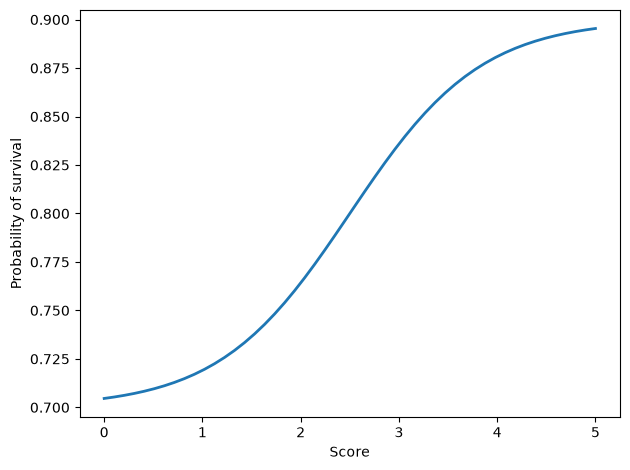

In [27]:
scores = np.linspace(0, 5)
probs = prob_survive(scores)
plt.plot(scores, probs)
decorate(xlabel='Score', ylabel='Probability of survival')

`choose_dead` uses `prob_survive` to map from fitness to probability of surviving.

In [28]:
%%add_method_to PDSimulation

    def choose_dead(self, fits):
        """Choose which agents die in the next timestep.
        
        fits: fitness of each agent
        
        returns: indices of the chosen ones
        """
        ps = prob_survive(fits)
        n = len(self.agents)
        is_dead = np.random.random(n) > ps
        index_dead = np.nonzero(is_dead)[0]
        return index_dead

> NOTE: In the printed version of this chapter, there is an error in `choose_dead` that caused it to give the agents with the highest fitness the *highest* probability of dying, so it accidentally selected the agents with the worst outcomes. In this version of the chapter, the error has been corrected. So the results of the experiments are different, and many of the conclusions have been revised. Thanks to Graham Taylor, who reported this error, and Dmitry Biba, who confirmed it.

We might want to start with random agents.

In [29]:
def make_random_agents(n):
    """Make agents with random genotype.
    
    n: number of agents
    
    returns: sequence of agents
    """
    agents = [Agent(np.random.choice(['C', 'D'], size=7)) 
              for _ in range(n)]
    return agents

Or with all identical agents.

In [30]:
def make_identical_agents(n, values):
    """Make agents with the given genotype.
    
    n: number of agents
    values: sequence of 'C' and 'D'
    
    returns: sequence of agents
    """
    agents = [Agent(values) for _ in range(n)]
    return agents

Here are the instruments to compute various metrics.

`Niceness` measures the fraction of cooperation in the genotypes of the agents after each time step:

In [31]:
class Niceness(Instrument):
    """Fraction of cooperation in all genotypes."""
    label = 'Niceness'
        
    def update(self, sim):
        responses = np.array([agent.values for agent in sim.agents])
        metric = np.mean(responses == 'C')
        self.metrics.append(metric)

`responses` is an array with one row for each agent and one column for each element of the genome. `metric` is the fraction of elements that are `'C'`, averaged across agents.

`Opening` tracks the fraction of agents that cooperate in the first round:

In [32]:
class Opening(Instrument):
    """Fraction of agents that cooperate on the first round."""
    label = 'Opening'
        
    def update(self, sim):
        responses = np.array([agent.values[0] for agent in sim.agents])
        metric = np.mean(responses == 'C')
        self.metrics.append(metric)

`Retaliating` compares the number of elements in all genomes where an agent defects after the opponent defects (elements 2, 4, and 6) with the number of places where an agents defects after the opponent cooperates.

In [33]:
class Retaliating(Instrument):
    """Tendency to defect after opponent defects."""
    label = 'Retaliating'
        
    def update(self, sim):
        after_d = np.array([agent.values[2::2] for agent in sim.agents])
        after_c = np.array([agent.values[1::2] for agent in sim.agents])
        metric = np.mean(after_d == 'D') - np.mean(after_c == 'D')
        self.metrics.append(metric)

`Forgiving` checks whether agents might be more likely to cooperate after D-C in the previous two rounds, compared to C-D.

In [34]:
class Forgiving(Instrument):
    """Tendency to cooperate if opponent cooperates after defecting."""
    label = 'Forgiving'
        
    def update(self, sim):
        after_dc = np.array([agent.values[5] for agent in sim.agents])
        after_cd = np.array([agent.values[4] for agent in sim.agents])
        metric = np.mean(after_dc == 'C') - np.mean(after_cd == 'C')
        self.metrics.append(metric)

## Results

Suppose we start with a population of three agents: one always cooperates, one always defects, and one plays the TFT strategy. If we run `Tournament.melee` with this population, the cooperator gets 1.5 points per round, the TFT agent gets 1.9, and the defector gets 3.33. This result suggests that "always defect" should quickly become the dominant strategy.

But "always defect" contains the seeds of its own destruction. If nicer strategies are driven to extinction, the defectors have no one to take advantage of. Their fitness drops, and they become vulnerable to invasion by cooperators.

Based on this analysis, it is not easy to predict how the system will behave: will it find a stable equilibrium, or oscillate between various points in the genotype landscape? Let's run the simulation and find out!

I start with 100 identical agents who always defect, and run the simulation for 5000 steps:

In [35]:
tour = Tournament()

agents = make_identical_agents(100, list('DDDDDDD'))
sim = PDSimulation(tour, agents)

sim.add_instrument(MeanFitness())
sim.add_instrument(Niceness())
sim.add_instrument(Opening())
sim.add_instrument(Retaliating())
sim.add_instrument(Forgiving())

Run the simulation.  If you get a warning about `Mean of empty slice`, that's ok.

In [36]:
np.random.seed(17)
sim.run(5000)

/tmp/ipykernel_886041/603461869.py:6: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(sim.get_fitnesses())


And let's look at some results.

In [37]:
def plot_result(index, **options):
    """Plots the results of the indicated instrument.
    
    index: integer
    """
    sim.plot(index, **options)
    instrument = sim.instruments[index]
    print(np.mean(instrument.metrics[1000:]))
    decorate(xlabel='Time steps', 
                     ylabel=instrument.label)

The following figure shows mean fitness over time (using the `MeanFitness` instrument), where fitness is the average number of points scored per round of Prisoner's Dilemma.

1.9078428309589268
Saving figure to file figs/chap12-1


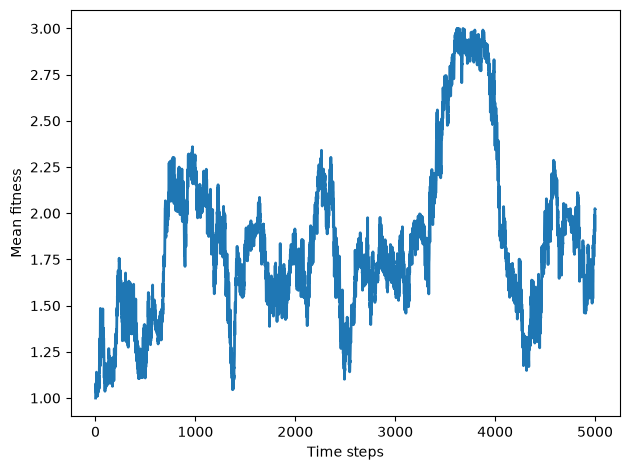

In [38]:
plot_result(0, color='C0')
savefig('figs/chap12-1')

Initially mean fitness is 1, because when defectors face each other, they get only 1 point each per round.

Mean fitness increases slowly, with ups and downs; after about 700 time steps, it is a little above 2. For most of the rest of the simulation, it oscillates between 1.5 and 2.25. Around time step 3500, it climbs close to 3, which is what cooperators get when they face each other. However, as we suspected, this situation is unstable. After a few hundred steps, mean fitness drops back below 2.

The rest of the simulation is highly variable, but mean fitness is usually below 2, with the long-term mean close to 1.9.

That's better than the dystopia of perpetual defection, but it's a long way from a utopia of cooperation, which would average 3 points per round. The long-term mean is about halfway between them.

To get some insight into this level of fitness, let's look at a few more instruments. The following figure shows average niceness across all genomes in the population (left), and the fraction of the population that cooperates in the first round (right).

0.3576545149426929
0.4257960509872532
Saving figure to file figs/chap12-2


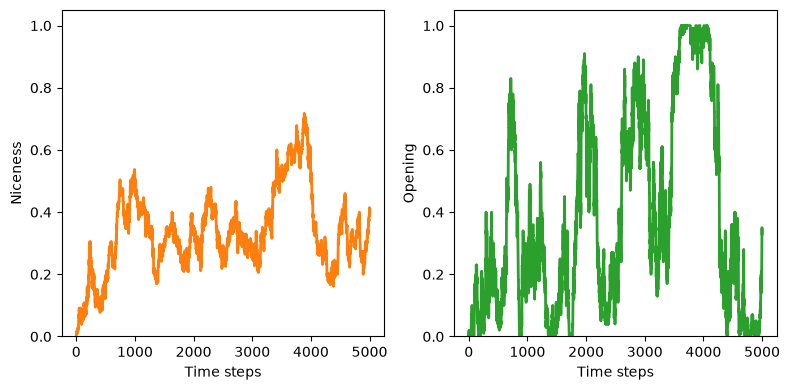

In [39]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)

plot_result(1, color='C1')
decorate(ylim=[0, 1.05])

plt.subplot(1,2,2)
plot_result(2, color='C2')
decorate(ylim=[0, 1.05])

savefig('figs/chap12-2')

Starting from 0, average niceness increases to about 0.5 after 1000 time steps, then oscillates, mostly between 0.2 and 0.5, with a long-term mean near 0.36. So most of the time, most of the elements in most genomes are defections.

> NOTE: In the printed version of this chapter, based on the incorrect version of `choose_dead`, the average niceness was substantially higher.

Looking specifically at the opening move, the results are highly variable. The fraction of agents who cooperate in the first round swings between near 0 and near 1, but it is low more often than high. The long-term average is close to 0.43, a little higher than overall niceness. Nice strategies sometimes take over the population, but they don't last. So these results are not consistent with what we might expect from Axelrod's tournaments, where nice strategies do well.

The other characteristics Axelrod identifies in successful strategies are retaliation and forgiveness. Here are the results from `Retaliating`.

0.05799383487461469


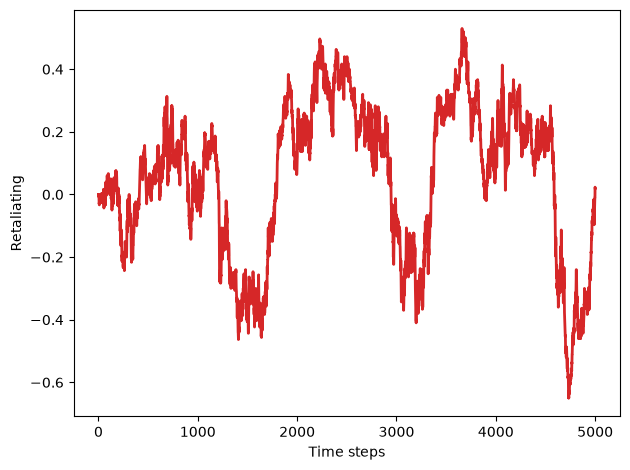

In [40]:
plot_result(3, color='C3')

As you might expect by now, the results are variable. On average the difference between these fractions is less than 0.1, so if agents defect 30% of the time after the opponent cooperates, they might defect 40% of the time after a defection.

This result provides weak support for the claim that successful strategies retaliate. But maybe it's not necessary for all agents, or even many, to be retaliatory; if there is at least some tendency toward retaliation in the population as a whole, that might be enough to prevent high-defection strategies from gaining ground.

And here are the results from `Forgiving`.

-0.1419370157460635


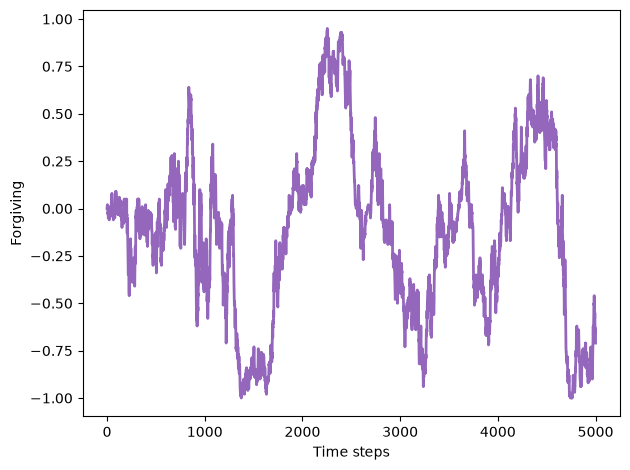

In [41]:
plot_result(4, color='C4')

In this simulation, there is no evidence for this particular kind of forgiveness. On the other hand, the strategies in these simulations are necessarily forgiving because they consider only the previous two rounds of history. In this context, forgetting is a kind of forgiving.

The following cells explore the composition of the final population.  But because the distribution of agents varies so much over time, the details of a single timestep might not mean much.

Here are the final genomes:

In [42]:
for agent in sim.agents:
    print(agent.values)

['D', 'D', 'C', 'C', 'C', 'D', 'D']
['D', 'C', 'D', 'D', 'C', 'D', 'D']
['D', 'C', 'D', 'C', 'C', 'D', 'D']
['D', 'C', 'D', 'D', 'C', 'C', 'D']
['D', 'C', 'D', 'D', 'C', 'D', 'D']
['C', 'C', 'D', 'D', 'C', 'C', 'D']
['C', 'C', 'D', 'D', 'C', 'C', 'D']
['D', 'C', 'D', 'D', 'C', 'D', 'D']
['D', 'C', 'D', 'D', 'C', 'D', 'D']
['D', 'C', 'D', 'D', 'C', 'D', 'D']
['C', 'C', 'D', 'D', 'C', 'D', 'D']
['C', 'C', 'D', 'D', 'C', 'D', 'D']
['D', 'D', 'C', 'D', 'C', 'D', 'D']
['D', 'C', 'D', 'D', 'C', 'D', 'D']
['C', 'C', 'D', 'D', 'C', 'D', 'D']
['D', 'C', 'D', 'D', 'C', 'D', 'D']
['D', 'C', 'D', 'D', 'C', 'D', 'D']
['C', 'C', 'D', 'D', 'C', 'D', 'D']
['D', 'C', 'D', 'D', 'C', 'D', 'D']
['C', 'C', 'D', 'D', 'C', 'D', 'D']
['D', 'C', 'D', 'D', 'C', 'D', 'D']
['D', 'C', 'C', 'D', 'C', 'D', 'D']
['D', 'C', 'D', 'D', 'C', 'D', 'D']
['C', 'C', 'D', 'D', 'C', 'D', 'D']
['D', 'C', 'D', 'D', 'C', 'D', 'D']
['D', 'C', 'D', 'D', 'C', 'D', 'D']
['D', 'C', 'D', 'D', 'C', 'D', 'D']
['D', 'D', 'C', 'C', 'C', 'D

And here are the most common genomes:

In [43]:
from pandas import Series

responses = [''.join(agent.values) for agent in sim.agents]
Series(responses).value_counts()

DCDDCDD    32
CCDDCCD    19
CCDDCDD    13
DDCCCDD    10
DCDCCDD     7
DCDDCCD     5
DDCDCDD     3
DDDDCDD     3
DCCDCDD     2
DDCDDCC     2
DCDDCDC     2
CDCCCDD     1
DCDDDDD     1
Name: count, dtype: int64

> NOTE: In the printed version of this chapter, with the incorrect `choose_dead`, the most common genomes were different. Most of them, like `DCDCDCD` and `DCDCCCD`, defect in the first round and then play like TFT: they cooperate as long as the opponent cooperates. In this version, the most common genomes, like `DCDDCDD` and `CCDDCCD`, still copy the opponent in the second round, but after the opponent cooperates twice in a row, they defect -- that is, they take advantage of cooperators.

## Conclusions

Axelrod's tournaments suggest a possible resolution to the problem of altruism: maybe being nice, but not *too* nice, is adaptive. But the strategies in the original tournaments were designed by people, not evolution, and the distribution of strategies did not change over the course of the tournaments.

So that raises a question: strategies like TFT might do well in a fixed population of human-designed strategies, but can they evolve? In other words, can they appear in a population through mutation, compete successfully with their ancestors, and resist invasion by their descendants?

The simulations in this chapter suggest:

-   Populations of defectors are vulnerable to invasion by nicer strategies.

-   Populations that are too nice are vulnerable to invasion by defectors.

-   As a result, the average level of niceness oscillates, but it is generally low, and the average level of fitness is about halfway between a dystopia of defection and a utopia of cooperation.

-   TFT, which was a successful strategy in Alexrod's tournaments, does not seem to be a specially optimal strategy in an evolving population. In fact, there is probably no stable optimal strategy.

-   Some degree of retaliation may be adaptive, but it might not be necessary for all agents to retaliate. If there is enough retaliation in the population as a whole, that might be enough to prevent invasion by defectors. (And that introduces a whole new topic in game theory, the free-rider problem; see <https://thinkcomplex.com/rider>.)

Obviously, the agents in these simulations are simple, and the Prisoner's Dilemma is a highly abstract model of a limited range of social interactions. In this model, cooperation appears from time to time, but it doesn't last: when the population is nice, defectors invade, and most of the time, most agents defect.

So this model, by itself, does not explain how altruism could evolve. That doesn't mean altruism is not adaptive; it means that something is missing from the model. The other explanations I mentioned at the beginning of the chapter -- sexual selection, kin selection, and group selection -- suggest what that might be, and some of the following exercises explore changes to the model that might make a difference.

## Exercises

**Exercise:** The simulations in this chapter depend on conditions and parameters I chose arbitrarily. As an exercise, I encourage you to explore other conditions to see what effect they have on the results. Here are some suggestions:

1.  Vary the initial conditions: instead of starting with all defectors, see what happens if you start with all cooperators, all TFT, or random agents.

2.  In `Tournament.melee`, I shuffle the agents at the beginning of each time step, so each agent plays against two randomly-chosen agents. What happens if you don't shuffle? In that case, each agent plays against the same neighbors repeatedly. That might make it easier for a minority strategy to invade a majority, by taking advantage of locality.

3.  Since each agent only plays against two other agents, the outcome of each round is highly variable: an agent that would do well against most other agents might get unlucky during any given round, or the other way around. What happens if you increase the number of opponents each agent plays against during each round? Or what if an agent's fitness at the end of each step is the average of its current score and its fitness at the end of the previous round?

4.  The function I chose for `prob_survival` varies from 0.7 to 0.9, so the least fit agent, with `p=0.7`, lives for 3.33 time steps on average, and the most fit agent lives for 10 time steps. What happens if you make the degree of differential survival more or less "aggressive"?

5.  I chose `num_rounds=6` so that each element of the genome has roughly the same impact on the outcome of a match. But that is substantially shorter than what Alexrod used in his tournaments. What happens if you increase `num_rounds`? Note: if you explore the effect of this parameter, you might want to modify `Niceness` to measure the niceness of the last 4 elements of the genome, which will be under more selective pressure as `num_rounds` increases.

6.  My implementation has differential survival but not differential reproduction. What happens if you add differential reproduction?

**Exercise:** In my simulations, the population never converges to a state where a majority share the same, presumably optimal, genotype. There are two possible explanations for this outcome: one is that there is no optimal strategy, because whenever the population is dominated by a majority genotype, that condition creates an opportunity for a minority to invade; the other possibility is that the mutation rate is high enough to maintain a diversity of genotypes.

To distinguish between these explanations, try lowering the mutation rate to see what happens. Alternatively, start with a random population and run without mutation until only one genotype survives. Or run with mutation until the system reaches something like a steady state; then turn off mutation and run until there is only one surviving genotype. What are the characteristics of the genotypes that prevail in these conditions?

**Exercise:** The agents in my experiment are "reactive" in the sense that their choice during each round depends only on what the opponent did during previous rounds. Explore strategies that also take into account the agent's past choices. These strategies can distinguish an opponent who retaliates from an opponent who defects without provocation.

[Think Complexity, 2nd Edition](https://greenteapress.com/wp/think-complexity-2e/)

Copyright 2016 [Allen B. Downey](https://allendowney.com)

Code license: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)